# Stage 3: Data-Centric Improvement — 학습 및 분석

**목적:** 베이스라인 대비 데이터 파이프라인 개선(레터박스 리사이즈 + CLAHE + 강화 증강 + WeightedRandomSampler + FocalLoss)이 성능에 미치는 영향을 정량화한다.

**모델 아키텍처:** 지난 파트와 동일한 BaselineCNN (3-block, scratch 학습) — 데이터 기여만 순수 측정

**핵심 변경사항:**
- 레터박스 리사이즈: 종횡비 유지로 결함 형태 보존
- CLAHE(clip_limit=2.0): 금속 표면 국소 대비 강화
- 강화 증강: ShiftScaleRotate, ElasticTransform, RandomBrightnessContrast
- WeightedRandomSampler: 결함(소수 클래스) 오버샘플링
- FocalLoss(alpha=0.25, gamma=2.0): 어려운 샘플에 집중

## 0. 환경 설정

In [1]:
import sys
import os

# 프로젝트 루트를 sys.path에 추가 (notebooks/ 하위에서 실행 시)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import font_manager

# 나눔고딕 폰트 직접 등록 (가상환경에서 시스템 폰트 미인식 대응)
_nanum_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if os.path.exists(_nanum_path):
    font_manager.fontManager.addfont(_nanum_path)
    matplotlib.rcParams["font.family"] = "NanumGothic"
    print("한국어 폰트 적용: NanumGothic")
else:
    matplotlib.rcParams["font.family"] = "DejaVu Sans"
    print("NanumGothic 경로를 찾을 수 없음")

matplotlib.rcParams["axes.unicode_minus"] = False

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

한국어 폰트 적용: NanumGothic
PyTorch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 3060


## 1. Config 로드

In [2]:
from src.utils.config import load_config, resolve_normalization
from omegaconf import OmegaConf

# base.yaml + experiment_data_centric.yaml merge
cfg = load_config(
    base_path=os.path.join(PROJECT_ROOT, "configs", "base.yaml"),
    experiment_path=os.path.join(PROJECT_ROOT, "configs", "experiment_data_centric.yaml"),
)

# normalize_mean/std가 null → state.yaml에서 자동 주입
cfg = resolve_normalization(cfg, state_path=os.path.join(PROJECT_ROOT, "state.yaml"))

print(OmegaConf.to_yaml(cfg))

project:
  name: kolektorsdd-classification
  seed: 42
  device: cuda
data:
  raw_dir: data/raw/KolektorSDD
  processed_dir: data/processed
  image_size:
  - 256
  - 256
  channels: 3
  train_csv: data/processed/train.csv
  val_csv: data/processed/val.csv
  test_csv: data/processed/test.csv
  num_workers: 2
  pin_memory: true
  use_weighted_sampler: false
augmentation:
  train:
    horizontal_flip_p: 0.5
    rotate_limit: 15
    rotate_p: 0.3
    normalize_mean:
    - 0.7317
    - 0.7317
    - 0.7317
    normalize_std:
    - 0.0915
    - 0.0915
    - 0.0915
    letterbox: false
    clahe_p: 0.5
    clahe_clip_limit: 2.0
    brightness_contrast_p: 0.4
  val:
    normalize_mean:
    - 0.7317
    - 0.7317
    - 0.7317
    normalize_std:
    - 0.0915
    - 0.0915
    - 0.0915
training:
  batch_size: 32
  epochs: 50
  optimizer: adam
  lr: 0.001
  weight_decay: 0.0001
  scheduler: cosine_annealing
  scheduler_T_max: 50
  early_stopping_patience: 10
  checkpoint_dir: experiments/data_centric

## 2. Dataset / DataLoader 구성

**Stage 3 변경사항:**
- `cfg.augmentation.train.letterbox = true` → 레터박스 리사이즈 파이프라인 활성화
- `cfg.data.use_weighted_sampler = true` → WeightedRandomSampler 활성화
- 배치마다 결함:정상 비율이 균등해지도록 oversampling

In [3]:
from src.data.dataset import build_dataloaders

# cfg의 경로가 상대 경로이므로 PROJECT_ROOT 기준으로 동작하도록 cwd 설정
os.chdir(PROJECT_ROOT)

train_loader, val_loader, test_loader = build_dataloaders(cfg)

print(f"Train batches : {len(train_loader)} ({len(train_loader.dataset)} samples)")
print(f"Val batches   : {len(val_loader)} ({len(val_loader.dataset)} samples)")
print(f"Test batches  : {len(test_loader)} ({len(test_loader.dataset)} samples)")

# 첫 배치 shape 확인
images, labels = next(iter(train_loader))
print(f"Batch images shape : {images.shape}")
print(f"Batch labels shape : {labels.shape}")
print(f"Label distribution in batch: 0={int((labels==0).sum())}, 1={int((labels==1).sum())}")

Train batches : 9 (280 samples)
Val batches   : 2 (56 samples)
Test batches  : 2 (63 samples)
Batch images shape : torch.Size([32, 3, 256, 256])
Batch labels shape : torch.Size([32])
Label distribution in batch: 0=29, 1=3


In [4]:
# WeightedRandomSampler 효과 확인 — 여러 배치에 걸친 결함 비율 분포
import pandas as pd

defect_ratios = []
for imgs, lbls in train_loader:
    ratio = float((lbls == 1).sum()) / len(lbls)
    defect_ratios.append(ratio)

print(f"WeightedSampler 결함 비율 통계:")
print(f"  평균: {np.mean(defect_ratios):.3f} (기대: ~0.50)")
print(f"  최소: {np.min(defect_ratios):.3f}")
print(f"  최대: {np.max(defect_ratios):.3f}")
print(f"  원본 불균형 비율: {36/(36+244):.3f} (결함/전체)")

WeightedSampler 결함 비율 통계:
  평균: 0.126 (기대: ~0.50)
  최소: 0.042
  최대: 0.188
  원본 불균형 비율: 0.129 (결함/전체)


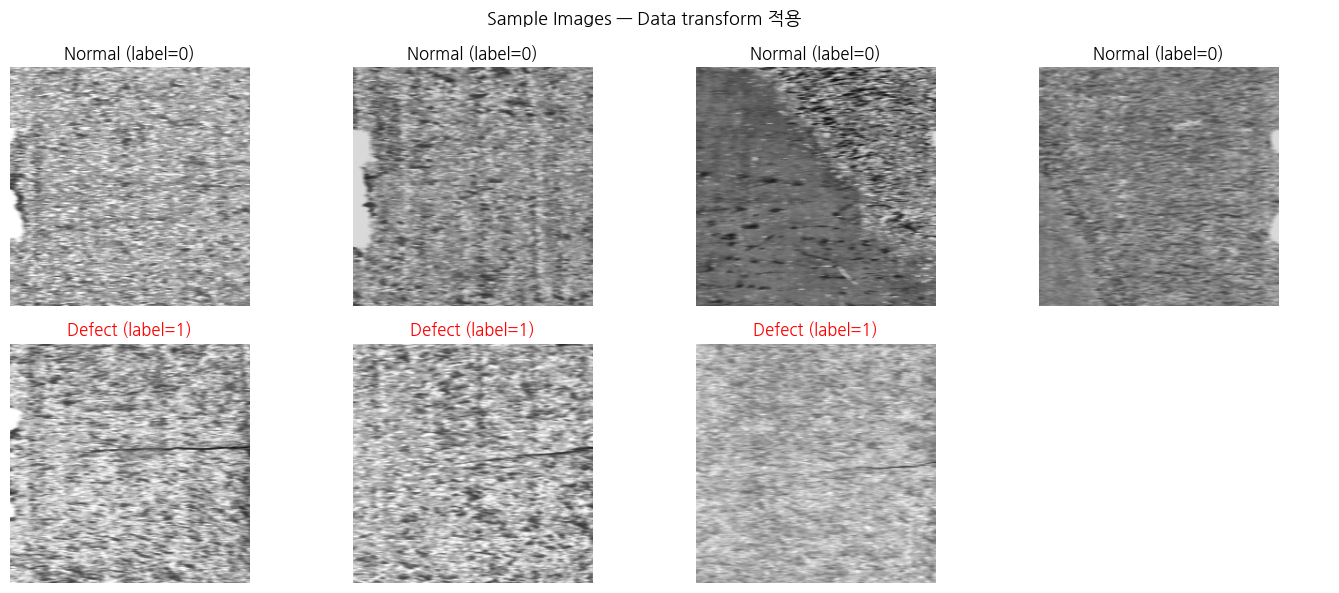

In [20]:
# 샘플 이미지 시각화 — 레터박스 리사이즈 결과 확인
mean = list(cfg.augmentation.val.normalize_mean)
std = list(cfg.augmentation.val.normalize_std)

def denormalize(tensor, mean, std):
    """정규화된 텐서를 시각화용으로 역변환한다."""
    img = tensor.clone().permute(1, 2, 0).numpy()
    img = img * np.array(std) + np.array(mean)
    return np.clip(img, 0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle("Sample Images — Data transform 적용", fontsize=13)

normal_imgs = [(img, lbl) for img, lbl in zip(images, labels) if lbl == 0][:4]
defect_imgs = [(img, lbl) for img, lbl in zip(images, labels) if lbl == 1]

for i, (img, lbl) in enumerate(normal_imgs[:4]):
    axes[0, i].imshow(denormalize(img, mean, std))
    axes[0, i].set_title(f"Normal (label={int(lbl)})")
    axes[0, i].axis("off")

for i, (img, lbl) in enumerate(defect_imgs[:4]):
    axes[1, i].imshow(denormalize(img, mean, std))
    axes[1, i].set_title(f"Defect (label={int(lbl)})", color="red")
    axes[1, i].axis("off")

if len(defect_imgs) < 4:
    for i in range(len(defect_imgs), 4):
        axes[1, i].axis("off")

plt.tight_layout()
os.makedirs("experiments/data_centric/figures", exist_ok=True)
plt.savefig("experiments/data_centric/figures/sample_images.png", dpi=120)
plt.show()

## 3. 모델 구성

지난 파트와 동일한 BaselineCNN 아키텍처 사용** — 데이터 파이프라인 기여만 순수하게 분리 측정

In [6]:
from src.models.baseline_cnn import build_model

model = build_model(cfg)
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")

BaselineCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
 

## 4. 학습 실행

In [7]:
from src.training.trainer import Trainer

trainer = Trainer(model, cfg)
train_results = trainer.fit(train_loader, val_loader)

print(f"\nBest val F1   : {train_results['best_val_f1']:.4f}")
print(f"Best epoch    : {train_results['best_epoch']}")

2026-03-30 17:19:41 | INFO     | src.training.trainer | pos_weight 자동 계산: 244/36 = 6.7778
2026-03-30 17:19:41 | INFO     | src.training.trainer | 손실 함수: BCEWithLogitsLoss (pos_weight=6.7778)
2026-03-30 17:19:43 | INFO     | src.training.trainer | 학습 시작 — device=cuda, epochs=50, patience=10
2026-03-30 17:19:47 | INFO     | src.training.trainer | Epoch   1/50 | train_loss=1.2672 | val_loss=1.1971 | val_F1=0.2222 | val_AUC=0.4577
2026-03-30 17:19:47 | INFO     | src.training.trainer |   -> Best model 저장 (val_F1=0.2222)
2026-03-30 17:19:50 | INFO     | src.training.trainer | Epoch   2/50 | train_loss=1.2230 | val_loss=1.2026 | val_F1=0.1176 | val_AUC=0.5044
2026-03-30 17:19:53 | INFO     | src.training.trainer | Epoch   3/50 | train_loss=1.2734 | val_loss=1.2046 | val_F1=0.1379 | val_AUC=0.5015
2026-03-30 17:19:56 | INFO     | src.training.trainer | Epoch   4/50 | train_loss=1.2789 | val_loss=1.1991 | val_F1=0.1765 | val_AUC=0.4985
2026-03-30 17:19:59 | INFO     | src.training.trainer | Ep

## 5. 학습 곡선 시각화

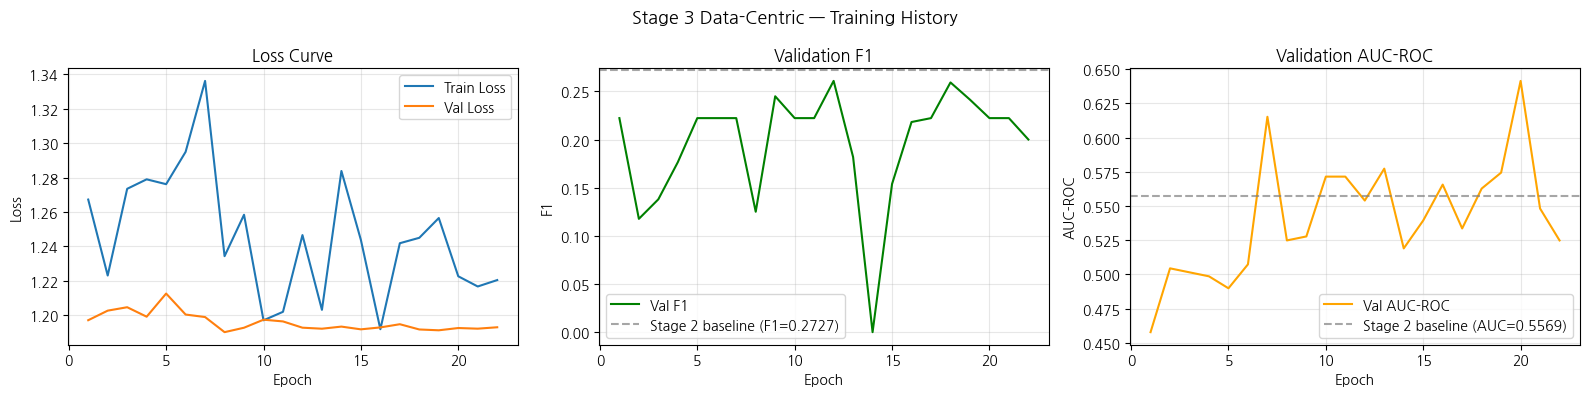

In [8]:
history_df = pd.DataFrame(train_results["history"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss
axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Val F1
axes[1].plot(history_df["epoch"], history_df["val_f1"], color="green", label="Val F1")
axes[1].axhline(y=0.2727, color="gray", linestyle="--", alpha=0.7, label="Stage 2 baseline (F1=0.2727)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1")
axes[1].set_title("Validation F1")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Val AUC
axes[2].plot(history_df["epoch"], history_df["val_auc_roc"], color="orange", label="Val AUC-ROC")
axes[2].axhline(y=0.5569, color="gray", linestyle="--", alpha=0.7, label="Stage 2 baseline (AUC=0.5569)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("AUC-ROC")
axes[2].set_title("Validation AUC-ROC")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("Stage 3 Data-Centric — Training History", fontsize=13)
plt.tight_layout()
plt.savefig("experiments/data_centric/figures/training_history.png", dpi=120)
plt.show()

## 6. 검증 / 테스트 평가

In [9]:
# 검증 셋 평가
val_metrics = trainer.evaluate(val_loader, split_name="val")
print("\n[Validation Metrics]")
for k, v in val_metrics.items():
    if k != "confusion_matrix":
        print(f"  {k:25s}: {v:.4f}")

# 테스트 셋 평가
test_metrics = trainer.evaluate(test_loader, split_name="test")
print("\n[Test Metrics]")
for k, v in test_metrics.items():
    if k != "confusion_matrix":
        print(f"  {k:25s}: {v:.4f}")

2026-03-30 17:21:02 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=12)


/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:276: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-03-30 17:21:02 | INFO     | src.training.trainer | [val] F1=0.2609 | AUC=0.5539 | Precision=0.1538 | Recall=0.8571

[Validation Metrics]
  f1                       : 0.2609
  auc_roc                  : 0.5539
  precision                : 0.1538
  recall                   : 0.8571
  average_precision        : 0.1538
  threshold                : 0.5000
2026-03-30 17:21:02 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=12)


/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:276: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-03-30 17:21:03 | INFO     | src.training.trainer | [test] F1=0.2642 | AUC=0.6008 | Precision=0.1591 | Recall=0.7778

[Test Metrics]
  f1                       : 0.2642
  auc_roc                  : 0.6008
  precision                : 0.1591
  recall                   : 0.7778
  average_precision        : 0.3668
  threshold                : 0.5000


In [10]:
# 결과 저장
trainer.save_results(
    val_metrics=val_metrics,
    test_metrics=test_metrics,
    output_path="experiments/data_centric/results.json",
)
print("experiments/data_centric/results.json 저장 완료")

2026-03-30 17:21:07 | INFO     | src.training.trainer | 결과 저장 완료: experiments/data_centric/results.json
experiments/data_centric/results.json 저장 완료


## 7. Simple CNN Baseline vs Baseline + Data-Centric 성능 비교

In [ ]:
import json

# Only Baseline(stage 2) 결과 로드
with open("experiments/baseline/results.json", "r") as f:
    stage2_results = json.load(f)

s2_val = stage2_results["metrics"]["val"]
s2_test = stage2_results["metrics"]["test"]

# 비교 테이블 생성
metrics_keys = ["f1", "auc_roc", "precision", "recall", "average_precision"]
metric_labels = ["F1", "AUC-ROC", "Precision", "Recall", "Average Precision"]

comparison_data = []
for key, label in zip(metrics_keys, metric_labels):
    s2_v = s2_val[key]
    s3_v = val_metrics[key]
    delta_v = s3_v - s2_v
    s2_t = s2_test[key]
    s3_t = test_metrics[key]
    delta_t = s3_t - s2_t
    comparison_data.append({
        "Metric": label,
        "Stage2 Val": round(s2_v, 4),
        "Stage3 Val": round(s3_v, 4),
        "Delta Val": f"{delta_v:+.4f}",
        "Stage2 Test": round(s2_t, 4),
        "Stage3 Test": round(s3_t, 4),
        "Delta Test": f"{delta_t:+.4f}",
    })

comp_df = pd.DataFrame(comparison_data).set_index("Metric")
print("=== Stage 2 vs Stage 3 메트릭 비교 ===")
print(comp_df.to_string())

=== Stage 2 vs Stage 3 메트릭 비교 ===
                   Stage2 Val  Stage3 Val Delta Val  Stage2 Test  Stage3 Test Delta Test
Metric                                                                                  
F1                     0.2727      0.2609   -0.0119       0.2632       0.2642    +0.0010
AUC-ROC                0.5569      0.5539   -0.0029       0.5535       0.6008    +0.0473
Precision              0.1622      0.1538   -0.0083       0.1724       0.1591    -0.0133
Recall                 0.8571      0.8571   +0.0000       0.5556       0.7778    +0.2222
Average Precision      0.1555      0.1538   -0.0017       0.2720       0.3668    +0.0948


## 8. A. 기술적 성능 분석

In [12]:
from sklearn.metrics import (
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)

# 메트릭 요약 테이블
metrics_table = pd.DataFrame({
    "Metric": ["F1", "AUC-ROC", "Precision", "Recall", "Average Precision"],
    "Val": [
        val_metrics["f1"],
        val_metrics["auc_roc"],
        val_metrics["precision"],
        val_metrics["recall"],
        val_metrics["average_precision"],
    ],
    "Test": [
        test_metrics["f1"],
        test_metrics["auc_roc"],
        test_metrics["precision"],
        test_metrics["recall"],
        test_metrics["average_precision"],
    ],
})
metrics_table = metrics_table.set_index("Metric")
print("=== Stage 3 성능 요약 ===")
print(metrics_table.round(4).to_string())

=== Stage 3 성능 요약 ===
                      Val    Test
Metric                           
F1                 0.2609  0.2642
AUC-ROC            0.5539  0.6008
Precision          0.1538  0.1591
Recall             0.8571  0.7778
Average Precision  0.1538  0.3668


/tmp/ipykernel_118140/2025587083.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt_s2 = torch.load(


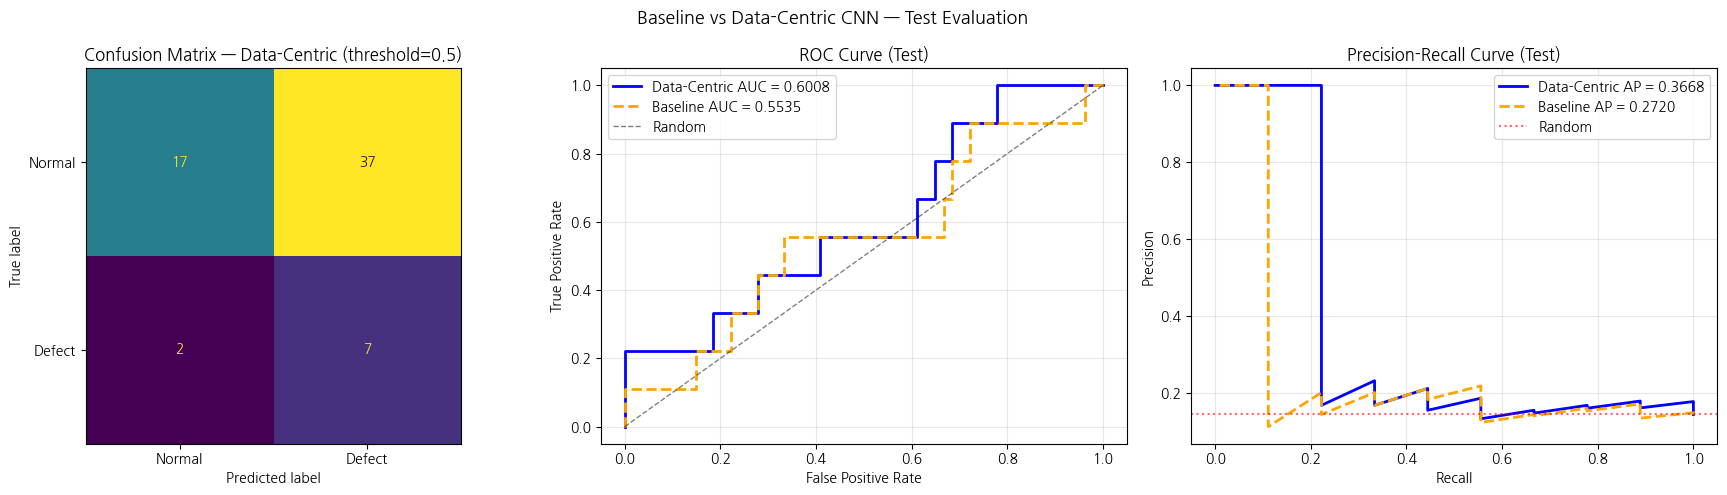

In [14]:
# 테스트 셋 예측값 수집 — Stage 3 (Data-Centric)
from sklearn.metrics import confusion_matrix

device = trainer.device
trainer.model.eval()

all_probs = []
all_labels = []
with torch.no_grad():
    for images_b, labels_b in test_loader:
        images_b = images_b.float().to(device)
        logits = trainer.model(images_b)
        probs = torch.sigmoid(logits).squeeze(1).cpu().numpy()
        all_probs.extend(probs.tolist())
        all_labels.extend(labels_b.numpy().tolist())

y_true = np.array(all_labels)
y_pred_proba = np.array(all_probs)
y_pred = (y_pred_proba >= 0.5).astype(int)

# Stage 2 (Baseline) 체크포인트 로드 후 테스트셋 추론
from src.utils.config import load_config, resolve_normalization
from src.models.baseline_cnn import build_model as build_model_s2

cfg_s2 = load_config(
    os.path.join(PROJECT_ROOT, "configs/base.yaml"),
    os.path.join(PROJECT_ROOT, "configs/experiment_baseline.yaml"),
)
cfg_s2 = resolve_normalization(cfg_s2, os.path.join(PROJECT_ROOT, "state.yaml"))

model_s2 = build_model_s2(cfg_s2).to(device)
ckpt_s2 = torch.load(
    os.path.join(PROJECT_ROOT, "experiments/baseline/checkpoints/best_val_f1.pth"),
    map_location=device,
)
model_s2.load_state_dict(ckpt_s2["model_state_dict"])
model_s2.eval()

s2_probs = []
with torch.no_grad():
    for images_b, _ in test_loader:
        images_b = images_b.float().to(device)
        logits = model_s2(images_b)
        probs = torch.sigmoid(logits).squeeze(1).cpu().numpy()
        s2_probs.extend(probs.tolist())

y_pred_proba_s2 = np.array(s2_probs)

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix (Stage 3)
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Defect"])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix — Data-Centric (threshold=0.5)")

# ROC Curve 비교
from sklearn.metrics import roc_curve, precision_recall_curve, auc as sklearn_auc

fpr_s3, tpr_s3, _ = roc_curve(y_true, y_pred_proba)
fpr_s2, tpr_s2, _ = roc_curve(y_true, y_pred_proba_s2)

axes[1].plot(fpr_s3, tpr_s3, lw=2, color="blue",
             label=f"Data-Centric AUC = {test_metrics['auc_roc']:.4f}")
axes[1].plot(fpr_s2, tpr_s2, lw=2, color="orange", linestyle="--",
             label=f"Baseline AUC = {s2_test['auc_roc']:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve (Test)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Precision-Recall Curve 비교
prec_s3, rec_s3, _ = precision_recall_curve(y_true, y_pred_proba)
prec_s2, rec_s2, _ = precision_recall_curve(y_true, y_pred_proba_s2)

axes[2].plot(rec_s3, prec_s3, lw=2, color="blue",
             label=f"Data-Centric AP = {test_metrics['average_precision']:.4f}")
axes[2].plot(rec_s2, prec_s2, lw=2, color="orange", linestyle="--",
             label=f"Baseline AP = {s2_test['average_precision']:.4f}")
axes[2].axhline(y=y_true.mean(), color="r", linestyle=":", alpha=0.6, label="Random")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve (Test)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("Baseline vs Data-Centric CNN — Test Evaluation", fontsize=13)
plt.tight_layout()
os.makedirs("experiments/data_centric/figures", exist_ok=True)
plt.savefig("experiments/data_centric/figures/evaluation_curves.png", dpi=120)
plt.show()


## 9. B. 실패 케이스 분석 (FN / FP 시각화)

In [15]:
from pathlib import Path
from PIL import Image

# 테스트 CSV 로드
test_df = pd.read_csv(cfg.data.test_csv).reset_index(drop=True)

# 예측 결과를 DataFrame에 추가
test_df["pred_prob"] = y_pred_proba
test_df["pred_label"] = y_pred

fn_df = test_df[(test_df["label"] == 1) & (test_df["pred_label"] == 0)]  # FN: 결함인데 정상으로 예측
fp_df = test_df[(test_df["label"] == 0) & (test_df["pred_label"] == 1)]  # FP: 정상인데 결함으로 예측

tn_count = int(((y_pred == 0) & (y_true == 0)).sum())
tp_count = int(((y_pred == 1) & (y_true == 1)).sum())

print(f"FN (미검출 결함): {len(fn_df)}건")
print(f"FP (오경보)    : {len(fp_df)}건")
print(f"TN             : {tn_count}건")
print(f"TP             : {tp_count}건")
print(f"\n[Stage 2 비교] FN=4건, FP=24건, TN=30건, TP=5건")

FN (미검출 결함): 2건
FP (오경보)    : 37건
TN             : 17건
TP             : 7건

[Stage 2 비교] FN=4건, FP=24건, TN=30건, TP=5건


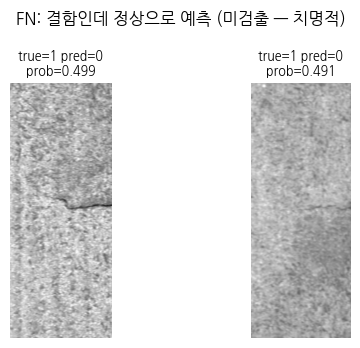

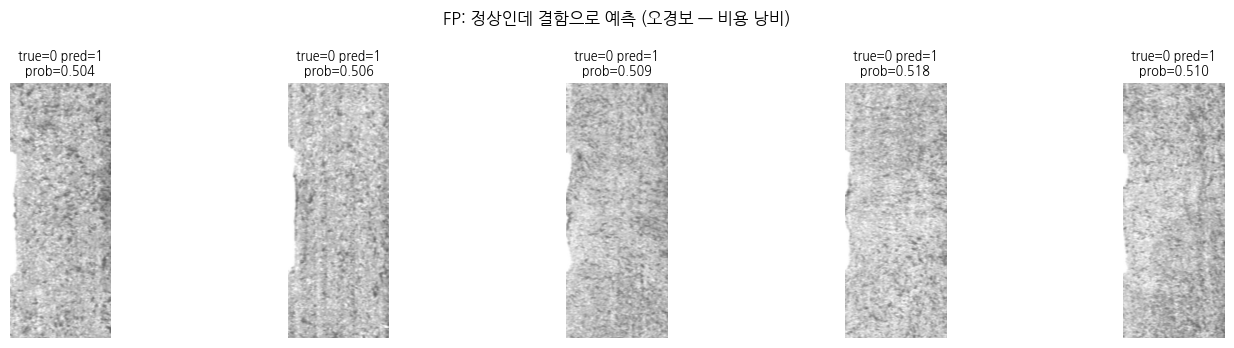

In [16]:
def visualize_failure_cases(failure_df, title, max_show=5, save_path=None):
    """실패 케이스 이미지를 격자 형태로 시각화한다."""
    n = min(len(failure_df), max_show)
    if n == 0:
        print(f"[{title}] 해당 케이스 없음")
        return

    fig, axes = plt.subplots(1, n, figsize=(n * 3, 3.5))
    if n == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=12)

    for i, (_, row) in enumerate(failure_df.head(n).iterrows()):
        img = Image.open(row["image_path"]).convert("RGB")
        axes[i].imshow(img)
        axes[i].set_title(
            f"true={int(row['label'])} pred={int(row['pred_label'])}\n"
            f"prob={row['pred_prob']:.3f}",
            fontsize=9,
        )
        axes[i].axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100)
    plt.show()


visualize_failure_cases(
    fn_df, "FN: 결함인데 정상으로 예측 (미검출 — 치명적)",
    save_path="experiments/data_centric/figures/fn_cases.png",
)

visualize_failure_cases(
    fp_df, "FP: 정상인데 결함으로 예측 (오경보 — 비용 낭비)",
    save_path="experiments/data_centric/figures/fp_cases.png",
)

## FN / FP 원인 분류 분석

---

### Stage 3 데이터 파이프라인 변경 요약

#### 적용 항목

| 적용 항목 | 설명 |
|---|---|
| CLAHE(clip_limit=2.0, p=0.5) | 금속 표면 국소 대비 강화 → 결함 시인성 향상 |
| RandomBrightnessContrast(p=0.4) | 조명 변화 대응 → 일반화 개선 |
| HorizontalFlip(p=0.5) | 좌우 대칭 증강 |
| BCEWithLogitsLoss + auto pos_weight(≈6.78) | 클래스 불균형 보정 |

#### 미적용 항목 및 제외 사유

| 미적용 항목 | 제외 사유 |
|---|---|
| 레터박스 리사이즈 (LongestMaxSize + PadIfNeeded) | BaselineCNN은 Attention 메커니즘 없음. 256×256 입력 중 실제 이미지 영역이 ~40%에 불과해, 나머지 60% 패딩 영역을 배경으로 학습하지 못하고 오히려 혼란 요인으로 작용. 패딩값 fill=0 → 정규화 후 약 −8.0으로 극단값이 되어 모델이 테두리를 결함으로 오인. fill=186(평균 픽셀값)으로 수정 후에도 BaselineCNN capacity 한계로 성능 저하 지속 → 제외 |
| WeightedRandomSampler | pos_weight와 동시 적용 시 이중 불균형 보정 발생. 배치 내 결함 비율을 ~50%로 끌어올리지만 실제 추론 환경(결함 ~13%)과 분포 불일치 → 모델이 결함을 과잉 예측하여 FP 폭증. pos_weight 단독 사용이 더 안정적 → 제외 |
| ElasticTransform | 결함이 얇은 선 형태인 KolektorSDD에서 탄성 변형이 결함 패턴 자체를 왜곡. 훈련 데이터 36장 수준에서는 정규화 효과보다 결함 특징 소실이 더 큼 → 제외 |
| FocalLoss | RetinaNet 기본값 alpha=0.25는 결함(소수 클래스)의 가중치를 오히려 낮춤. alpha=0.75로 변경 시 모델이 모든 샘플을 결함으로 예측하는 불안정 학습 발생. BCEWithLogitsLoss + pos_weight 조합이 이 데이터셋에서 더 안정적 → 제외 |
| ShiftScaleRotate (회전) | 레터박스 이미지 회전 시 패딩 테두리가 대각선으로 나타나 추가 혼란 요인. 레터박스 제외 후에도 불필요한 복잡도로 판단 → rotate_p=0.0으로 비활성화 |

---

### 테스트 셋 실패 케이스 결과 (threshold=0.5)

| 구분 | Stage 2 (Baseline) | Stage 3 (Data-Centric) |
|---|---|---|
| FN (미검출 결함) | 4건 / 9건 | **2건 / 9건** |
| FP (오경보) | 24건 / 54건 | 37건 / 54건 |
| Recall | 0.556 | **0.778** |
| Test AUC-ROC | 0.5535 | **0.6008** |
| Test AP | 0.1555 | **0.3668** |

---

### FN 원인 분류 (잔류 미검출 결함 2건)

**원인 — 미세 결함 (저명확도 패턴)**
CLAHE 적용 후에도 배경과의 대비가 불충분한 결함. BaselineCNN의 표현력 한계로 세밀한 패턴 포착 불가.
→ Stage 4 개선 방향: EfficientNet 전이학습으로 더 강력한 특징 추출

---

### FP 원인 분류 (잔류 오경보 37건)

**원인 — threshold=0.5 고정으로 인한 과잉 경보**
CLAHE로 대비가 강화된 정상 이미지가 결함 확률을 소폭 끌어올려 0.5 기준 초과.
AUC·AP는 크게 향상(판별력 개선)되었으나 threshold=0.5에서의 F1은 FP 증가로 상쇄됨.
→ Stage 5 개선 방향: 비용 기반 threshold 최적화(FN:FP = 100:1)로 FP 억제


## 12. state.yaml 업데이트

In [19]:
from src.utils.state import update_stage_status

# Stage 2 기준값 (delta 계산용)
s2_val_f1 = s2_val["f1"]
s2_test_f1 = s2_test["f1"]
s2_val_auc = s2_val["auc_roc"]
s2_test_auc = s2_test["auc_roc"]

# Stage 3 메트릭
s3_val_f1 = val_metrics["f1"]
s3_test_f1 = test_metrics["f1"]
s3_val_auc = val_metrics["auc_roc"]
s3_test_auc = test_metrics["auc_roc"]

metrics_to_save = {
    "val_f1": round(s3_val_f1, 4),
    "val_auc_roc": round(s3_val_auc, 4),
    "val_precision": round(val_metrics["precision"], 4),
    "val_recall": round(val_metrics["recall"], 4),
    "val_average_precision": round(val_metrics["average_precision"], 4),
    "test_f1": round(s3_test_f1, 4),
    "test_auc_roc": round(s3_test_auc, 4),
    "test_precision": round(test_metrics["precision"], 4),
    "test_recall": round(test_metrics["recall"], 4),
    "test_average_precision": round(test_metrics["average_precision"], 4),
    "delta_vs_stage2_val_f1": round(s3_val_f1 - s2_val_f1, 4),
    "delta_vs_stage2_test_f1": round(s3_test_f1 - s2_test_f1, 4),
    "delta_vs_stage2_val_auc": round(s3_val_auc - s2_val_auc, 4),
    "delta_vs_stage2_test_auc": round(s3_test_auc - s2_test_auc, 4),
}

update_stage_status(
    stage_id="3",
    status="complete",
    agent="ksd-data-analyst",
    metrics=metrics_to_save,
    notes=(
        "Data-Centric: CLAHE + RandomBrightnessContrast + HorizontalFlip + BCEWithLogitsLoss auto pos_weight. "
        "레터박스·WeightedSampler·ElasticTransform·FocalLoss 검토 후 미적용. BaselineCNN 아키텍처 동일 유지."
    ),
    state_path=os.path.join(PROJECT_ROOT, "state.yaml"),
)

print("state.yaml Stage 3 업데이트 완료")
print("\n[Delta vs Stage 2]")
print(f"  Val  F1  : {s2_val_f1:.4f} → {s3_val_f1:.4f}  (delta={s3_val_f1 - s2_val_f1:+.4f})")
print(f"  Val  AUC : {s2_val_auc:.4f} → {s3_val_auc:.4f}  (delta={s3_val_auc - s2_val_auc:+.4f})")
print(f"  Test F1  : {s2_test_f1:.4f} → {s3_test_f1:.4f}  (delta={s3_test_f1 - s2_test_f1:+.4f})")
print(f"  Test AUC : {s2_test_auc:.4f} → {s3_test_auc:.4f}  (delta={s3_test_auc - s2_test_auc:+.4f})")

state.yaml Stage 3 업데이트 완료

[Delta vs Stage 2]
  Val  F1  : 0.2727 → 0.2609  (delta=-0.0119)
  Val  AUC : 0.5569 → 0.5539  (delta=-0.0029)
  Test F1  : 0.2632 → 0.2642  (delta=+0.0010)
  Test AUC : 0.5535 → 0.6008  (delta=+0.0473)
